## Class 03 Versionamiento

#### Sección 0 — Instalación y Configuración del Entorno

In [1]:
# ── 0.2 Configurar directorio de trabajo Local (WSL) ───────────────────────────
import os

# CAMBIO CLAVE: Usamos una ruta relativa. 
# Esto creará la carpeta 'banco-wiesse-mlops' dentro de tu directorio actual.
PROJECT_DIR = os.path.abspath("./banco-wiesse-mlops")
os.makedirs(PROJECT_DIR, exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Directorio de trabajo: {os.getcwd()}")
print()

# Crear estructura de carpetas estándar de MLOps
for folder in ["data", "src", "tests", "models", "notebooks"]:
    os.makedirs(folder, exist_ok=True)
    print(f"  📁 {folder}/")

print()
print("✅ Estructura de carpetas creada localmente")

Directorio de trabajo: /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops

  📁 data/
  📁 src/
  📁 tests/
  📁 models/
  📁 notebooks/

✅ Estructura de carpetas creada localmente


#### Sección 1 — Crear el Dataset y la Estructura Base

Generamos un dataset sintético que replica las características del dataset real de
endeudamiento crediticio del Banco Wiesse. Tiene las mismas 11 columnas, distribución
de default ~17% y valores NA como string en dos columnas (como el original).

In [4]:
# =====================================================================
#  EJECUTA ESTA CELDA COMPLETA (GENERACIÓN Y GUARDADO UNIFICADO)
# =====================================================================
from pathlib import Path
import pandas as pd
import numpy as np

# 1. Configuración defensiva de rutas
cwd = Path.cwd()

# Si ya estamos dentro de la carpeta del proyecto, no la duplicamos
if cwd.name == "banco-wiesse-mlops":
    NUCLEO_PROYECTO = cwd
else:
    NUCLEO_PROYECTO = cwd / "banco-wiesse-mlops"

CARPETA_DATA = NUCLEO_PROYECTO / "data"
CARPETA_DATA.mkdir(parents=True, exist_ok=True)

ruta_csv = CARPETA_DATA / "Dataset Endeudamiento Crediticio.csv"

# 2. Generación del Dataset Sintético
np.random.seed(42)
N = 1850  

n_default = int(N * 0.172)   
n_no_default = N - n_default

def generar_cliente(default, n):
    """Genera clientes con distribuciones realistas según su estado de default."""
    if default == 1:
        return {
            "Prct_uso_tc":               np.random.beta(2, 1.5, n).round(4),
            "Nro_prestao_retrasados":   np.random.poisson(2.8, n),
            "Prct_deuda_vs_ingresos":   np.random.beta(2, 2, n).round(4),
            "Mto_ingreso_mensual":      np.random.lognormal(7.8, 0.6, n).round(0),
            "Nro_prod_financieros_deuda": np.random.poisson(7, n),
            "Nro_retraso_60dias":       np.random.poisson(1.2, n),
            "Nro_creditos_hipotecarios": np.random.poisson(0.8, n),
            "Edad":                     np.random.randint(21, 75, n),
            "Nro_retraso_ultm3anios":   np.random.poisson(2.5, n),
            "Nro_dependiente":          np.random.randint(0, 6, n).astype(float),
        }
    else:
        return {
            "Prct_uso_tc":               np.random.beta(1.5, 2.5, n).round(4),
            "Nro_prestao_retrasados":   np.random.poisson(0.4, n),
            "Prct_deuda_vs_ingresos":   np.random.beta(1.5, 3, n).round(4),
            "Mto_ingreso_mensual":      np.random.lognormal(8.2, 0.5, n).round(0),
            "Nro_prod_financieros_deuda": np.random.poisson(4, n),
            "Nro_retraso_60dias":       np.random.poisson(0.1, n),
            "Nro_creditos_hipotecarios": np.random.poisson(1.2, n),
            "Edad":                     np.random.randint(21, 75, n),
            "Nro_retraso_ultm3anios":   np.random.poisson(0.3, n),
            "Nro_dependiente":          np.random.randint(0, 5, n).astype(float),
        }

d1 = generar_cliente(1, n_default)
d0 = generar_cliente(0, n_no_default)

df_parts = []
for d, target, n in [(d1, 1, n_default), (d0, 0, n_no_default)]:
    part = pd.DataFrame(d)
    part["Default"] = target
    df_parts.append(part)

df = pd.concat(df_parts, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
df.insert(0, "ID", range(1, N + 1))

# Introducir 'NA' como string en dos columnas
idx_monto = df.sample(frac=0.08, random_state=1).index
idx_deps  = df.sample(frac=0.06, random_state=2).index
df.loc[idx_monto, "Mto_ingreso_mensual"] = "NA"
df.loc[idx_deps,  "Nro_dependiente"]     = "NA"

# 3. GUARDADO FÍSICO DEL ARCHIVO
df.to_csv(ruta_csv, sep=";", index=False)

# 4. Reporte de verificación en consola
print("🔍 --- DIAGNÓSTICO DE CONTROL DE RUTAS ---")
print(f"📍 Directorio de ejecución (CWD) : {cwd}")
print(f"💾 Ruta objetivo de guardado      : {ruta_csv}")
print(f"📦 ¿El archivo existe en Linux?   : {'SÍ ✅' if ruta_csv.exists() else 'NO ❌'}")

🔍 --- DIAGNÓSTICO DE CONTROL DE RUTAS ---
📍 Directorio de ejecución (CWD) : /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops
💾 Ruta objetivo de guardado      : /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops/data/Dataset Endeudamiento Crediticio.csv
📦 ¿El archivo existe en Linux?   : SÍ ✅


/tmp/ipykernel_60078/3172670456.py:73: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx_monto, "Mto_ingreso_mensual"] = "NA"
/tmp/ipykernel_60078/3172670456.py:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NA' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx_deps,  "Nro_dependiente"]     = "NA"


In [5]:
# ── 1.2 Vista previa del dataset ────────────────────────────────────────────
df_preview = pd.read_csv(ruta_csv, sep=";")
print(f"Shape: {df_preview.shape}")
print()
df_preview.head(8)

Shape: (1850, 12)



,ID,Prct_uso_tc,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Edad,Nro_retraso_ultm3anios,Nro_dependiente,Default
0,1,0.8331,2,0.8139,500.0,10,2,0,38,2,1.0,1
1,2,0.2825,0,0.4782,4575.0,3,0,1,35,0,4.0,0
2,3,0.1099,1,0.0249,2941.0,6,0,1,30,0,4.0,0
3,4,0.6759,0,0.5778,2974.0,2,0,1,52,0,0.0,0
4,5,0.0868,0,0.0332,2314.0,2,0,1,47,0,NaN,0
5,6,0.4096,1,0.2276,1471.0,3,0,0,38,0,0.0,0
6,7,0.9040,0,0.5171,3060.0,6,0,0,39,1,3.0,0
7,8,0.2767,1,0.1439,4253.0,2,0,0,43,0,1.0,0


---
#### 🗄️ Sección 2 — Inicializar DVC y Versionar el Dataset

##### ¿Por qué DVC y no Git para los datos?

Git está diseñado para versionar **código** (archivos de texto pequeños).
Los datasets pueden pesar cientos de MB o GB — subirlos a Git haría el repositorio
inutilizable. DVC resuelve esto con un sistema de **punteros**:

```
Dataset real  →  .dvc/cache/  (pesado, NO en Git)
Puntero .dvc  →  Git          (ligero: solo hash MD5 + tamaño)
```

Cualquier colaborador hace `git pull` + `dvc pull` y obtiene exactamente el mismo dataset.

#### El Concepto de Desarrollador: DVC + Git (Mejores Amigos)

En un entorno profesional, **Git es el cerebro** y **DVC es el músculo**.
Cuando inicializas DVC dentro de un repositorio de Git activo, DVC se integra de forma nativa:

Tu Proyecto (banco-wiesse-mlops)
  ├── .git/          (Vigila tu código python)
  └── .dvc/          (Vigila tus datasets pesados)

Al estar conectados, cuando le dices a DVC que rastree un archivo, DVC automáticamente escribe en el archivo .gitignore de tu Git para que nunca subas por error un archivo pesado a GitHub. ¡Todo ocurre de forma automatizada!

In [6]:
# ── 2.1 Inicializar DVC en Subdirectorio ────────────────────────────────────
import os
import subprocess

# Inicializamos DVC con la bandera --subdir para no romper tu Git principal
if not os.path.exists(".dvc"):
    print("Inicializando DVC con aislamiento de subproyecto...")
    result_dvc = subprocess.run(["dvc", "init", "--subdir"], capture_output=True, text=True)
    if result_dvc.returncode == 0:
        print("✅ DVC inicializado con éxito en modo --subdir")
    else:
        print(f"❌ Error al inicializar DVC: {result_dvc.stderr}")
else:
    print("✅ DVC ya está inicializado en esta subcarpeta")

Inicializando DVC con aislamiento de subproyecto...
✅ DVC inicializado con éxito en modo --subdir


In [7]:
print("\n🚀 Comunicando cambios a Git...")

# Agregamos los archivos ligeros y de configuración al área de preparación (staging)
subprocess.run(["git", "add", ".gitignore", "README.md", ".dvcignore", ".dvc/config"])

# Confirmamos el commit
result_commit = subprocess.run(
    ["git", "commit", "-m", "init: estructura base del proyecto con DVC"],
    capture_output=True,
    text=True
)

# Imprimimos el resultado de Git para que veas qué pasó
if result_commit.returncode == 0:
    print("✅ ¡Commit realizado con éxito!")
else:
    print("ℹ️ Mensaje de Git (es posible que ya hayas hecho commit de estos archivos antes):")
    print(result_commit.stdout or result_commit.stderr)

# Mostramos el historial reciente
print("\n📋 Últimos commits en tu repositorio:")
subprocess.run(["git", "log", "--oneline", "-n", "3"])


🚀 Comunicando cambios a Git...
✅ ¡Commit realizado con éxito!

📋 Últimos commits en tu repositorio:
7465912 init: estructura base del proyecto con DVC
7fd8830 Class02: Modularidad
3412fbf creando vEnv_MLOps_Smartdata en thinkpad1


fatal: pathspec '.gitignore' did not match any files


CompletedProcess(args=['git', 'log', '--oneline', '-n', '3'], returncode=0)

DVC (El Bodeguero) tomó tu pesadísimo archivo de datos (Dataset Endeudamiento Crediticio.csv), le sacó una copia exacta, le puso una etiqueta con un código de barra único encriptado (el hash MD5, por ejemplo: 8b1a54...) y lo guardó bajo llave en la bodega segura de la empresa (.dvc/cache).

Luego, el bodeguero escribió una tarjeta de entrega ligera de papel (el archivo Dataset Endeudamiento Crediticio.csv.dvc) que dice: "El dataset original está guardado en la bodega con el código de barra 8b1a54...".

El bodeguero le entregó esa tarjeta a Git (El Archivista).

Git archivó la tarjeta en su archivero de metal (el historial de commits) sin hacer ningún esfuerzo físico, porque la tarjeta no pesa nada.

In [8]:
# ── 2.3 Versionar el dataset con DVC (Versión Local WSL) ──
import os
import subprocess
from pathlib import Path

# 1. Asegurar que estamos parados en la carpeta correcta
cwd = Path.cwd()
if cwd.name != "banco-wiesse-mlops":
    os.chdir("./banco-wiesse-mlops")
    cwd = Path.cwd()

# Reconstruimos las rutas de forma segura con Pathlib
NUCLEO_PROYECTO = cwd
CARPETA_DATA = NUCLEO_PROYECTO / "data"
ruta_csv = CARPETA_DATA / "Dataset Endeudamiento Crediticio.csv"
dvc_file = Path(f"{ruta_csv}.dvc")

print("⚡ Iniciando el versionamiento del dataset con DVC...")
print(f"📍 Dataset objetivo: {ruta_csv.name}")
print("-" * 55)

# 2. Ejecutar 'dvc add' usando subprocess
result_dvc = subprocess.run(
    ["dvc", "add", str(ruta_csv)],
    capture_output=True,
    text=True
)

if result_dvc.returncode == 0:
    print("✅ dvc add completado con éxito.")
    print(result_dvc.stdout)
else:
    print("❌ Error al registrar en DVC:")
    print(result_dvc.stderr)
    print("-" * 55)

# 3. Mostrar el contenido del archivo .dvc generado (tu "puntero")
if dvc_file.exists():
    print(f"\n📄 Contenido del archivo puntero ({dvc_file.name}):")
    print("-" * 40)
    with open(dvc_file, "r") as f:
        print(f.read())
    print("-" * 40)
else:
    print(f"❌ Alerta: No se encontró el archivo puntero {dvc_file}")

# 4. Hacer commit del puntero (.dvc) y del .gitignore que DVC creó en 'data/'
print("\n🚀 Guardando punteros en tu Git principal...")

# DVC crea automáticamente un .gitignore dentro de 'data/' para ignorar el CSV.
# Debemos registrar tanto el archivo '.dvc' como este nuevo '.gitignore' local.
dvc_gitignore = CARPETA_DATA / ".gitignore"

subprocess.run(["git", "add", str(dvc_file), str(dvc_gitignore)])

result_commit = subprocess.run(
    ["git", "commit", "-m", "data: versionar dataset crediticio Banco Wiesse v1.0"],
    capture_output=True,
    text=True
)

if result_commit.returncode == 0:
    print("✅ ¡Commit en Git realizado con éxito!")
    print("   El dataset ya está seguro en DVC y su puntero está guardado en Git.")
else:
    print("ℹ️ Mensaje de Git (es posible que ya hayas commiteado estos cambios previamente):")
    print(result_commit.stdout or result_commit.stderr)

⚡ Iniciando el versionamiento del dataset con DVC...
📍 Dataset objetivo: Dataset Endeudamiento Crediticio.csv
-------------------------------------------------------
✅ dvc add completado con éxito.

To track the changes with git, run:

	git add 'data/Dataset Endeudamiento Crediticio.csv.dvc' data/.gitignore

To enable auto staging, run:

	dvc config core.autostage true


📄 Contenido del archivo puntero (Dataset Endeudamiento Crediticio.csv.dvc):
----------------------------------------
outs:
- md5: ffae8c49bfa8318c7fcf6fd0dfbf0aca
  size: 81281
  hash: md5
  path: Dataset Endeudamiento Crediticio.csv

----------------------------------------

🚀 Guardando punteros en tu Git principal...
✅ ¡Commit en Git realizado con éxito!
   El dataset ya está seguro en DVC y su puntero está guardado en Git.


---
#### 🐍 Sección 3 — Crear los Módulos src/ (del Tema 2)

Escribimos los mismos módulos refactorizados del Tema 2 directamente en Colab
usando `%%writefile`. Esto crea los archivos Python en `src/` del proyecto.

In [9]:
# ── 3.1 - 3.4 Creación de Módulos en src/ (Versión Local WSL) ──────────────────
import os
from pathlib import Path

# 1. Asegurar ubicación en 'banco-wiesse-mlops'
cwd = Path.cwd()
if cwd.name != "banco-wiesse-mlops":
    os.chdir("./banco-wiesse-mlops")
    cwd = Path.cwd()

# 2. Asegurar que la carpeta 'src' exista físicamente
src_dir = cwd / "src"
src_dir.mkdir(exist_ok=True)
print(f"📁 Carpeta de destino: {src_dir}")
print("-" * 65)

# 3. Definir contenidos de los archivos de Python
modulos = {}

modulos["data_loader.py"] = """\"\"\"
data_loader.py — Carga y validación del dataset de riesgo crediticio Banco Wiesse.
\"\"\"
import logging
import pandas as pd
from pathlib import Path

logger = logging.getLogger(__name__)

COLUMNAS_REQUERIDAS = {
    'Default', 'Prct_uso_tc', 'Prct_deuda_vs_ingresos',
    'Mto_ingreso_mensual', 'Nro_dependiente', 'Edad',
    'Nro_prestao_retrasados', 'Nro_retraso_60dias',
    'Nro_prod_financieros_deuda', 'Nro_creditos_hipotecarios',
    'Nro_retraso_ultm3anios',
}

def cargar_datos(ruta: str) -> pd.DataFrame:
    \"\"\"
    Carga el CSV de endeudamiento crediticio (sep=';', decimal='.').
    \"\"\"
    path = Path(ruta)
    if not path.exists():
        raise FileNotFoundError(f'Archivo no encontrado: {ruta}')

    logger.info('Cargando datos desde %s', ruta)
    df = pd.read_csv(path, sep=';', decimal='.')

    faltantes = COLUMNAS_REQUERIDAS - set(df.columns)
    if faltantes:
        raise ValueError(f'Columnas faltantes en el dataset: {faltantes}')

    logger.info('Dataset cargado: %d filas x %d columnas', *df.shape)
    logger.info('Default dist: %s', df['Default'].value_counts().to_dict())
    return df
"""

modulos["preprocessing.py"] = """\"\"\"
preprocessing.py — Limpieza, winsorization, imputación y balanceo.
\"\"\"
import logging
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

logger = logging.getLogger(__name__)

COLUMNAS_NA_STRING   = ['Mto_ingreso_mensual', 'Nro_dependiente']
COLUMNAS_WINSORIZAR  = ['Prct_uso_tc', 'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual']

ESTRATEGIAS_DEFAULT = {
    'Mto_ingreso_mensual':       'median',
    'Nro_dependiente':           'mode',
    'Prct_deuda_vs_ingresos':    'median',
    'Prct_uso_tc':               'median',
    'Edad':                      'median',
    'Nro_prestao_retrasados':    'median',
    'Nro_prod_financieros_deuda':'median',
    'Nro_retraso_60dias':        'median',
    'Nro_creditos_hipotecarios': 'median',
    'Nro_retraso_ultm3anios':    'median',
}

def limpiar_na_strings(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in COLUMNAS_NA_STRING:
        if col in df.columns:
            antes = df[col].astype(str).str.upper().str.contains('NA', na=False).sum()
            df[col] = df[col].replace(['NA', 'na', 'Na', 'N/A'], np.nan)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            logger.info('%s: %d valores NA-string convertidos a NaN', col, antes)
    return df

def winsorizar_columnas(df: pd.DataFrame, columnas=None, p_low=0.05, p_high=0.95) -> pd.DataFrame:
    df = df.copy()
    cols = columnas or COLUMNAS_WINSORIZAR
    for col in cols:
        if col in df.columns and df[col].notna().any():
            lower = df[col].quantile(p_low)
            upper = df[col].quantile(p_high)
            n_out = ((df[col] < lower) | (df[col] > upper)).sum()
            df[col] = df[col].clip(lower=lower, upper=upper)
            logger.info('%s: %d outliers tratados [%.2f, %.2f]', col, n_out, lower, upper)
    return df

def imputar_nulos(df: pd.DataFrame, estrategias=None) -> pd.DataFrame:
    df = df.copy()
    estrategias = estrategias or ESTRATEGIAS_DEFAULT
    for col, strategy in estrategias.items():
        if col in df.columns and df[col].isnull().sum() > 0:
            n = df[col].isnull().sum()
            if strategy == 'median':   val = df[col].median()
            elif strategy == 'mean':   val = df[col].mean()
            else:                      val = df[col].mode()[0]
            df[col].fillna(val, inplace=True)
            logger.info('%s: %d nulos imputados con %s (%.4f)', col, n, strategy, val)
    return df

def dividir_y_balancear(X: pd.DataFrame, y: pd.Series, test_size=0.2, tecnica='smote', random_state=42) -> tuple:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    logger.info('Split: train=%d test=%d', len(y_train), len(y_test))

    samplers = {
        'smote':         SMOTE(random_state=random_state),
        'undersampling': RandomUnderSampler(random_state=random_state),
        'oversampling':  RandomOverSampler(random_state=random_state),
    }
    sampler = samplers.get(tecnica, SMOTE(random_state=random_state))
    X_train_b, y_train_b = sampler.fit_resample(X_train, y_train)
    logger.info('Balanceo %s: antes=%d despues=%d', tecnica, len(y_train), len(y_train_b))
    return X_train_b, X_test, y_train_b, y_test
"""

modulos["features.py"] = """\"\"\"
features.py — Feature engineering del proyecto Banco Wiesse.
\"\"\"
import logging
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

logger = logging.getLogger(__name__)

PESOS_RETRASOS = {
    'Nro_prestao_retrasados': 3,
    'Nro_retraso_60dias':     5,
    'Nro_retraso_ultm3anios': 2,
}

COLUMNAS_ESCALAR = [
    'Prct_uso_tc', 'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual',
    'Edad', 'Nro_prestao_retrasados', 'Score_retrasos',
]

def crear_score_retrasos(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Score_retrasos'] = sum(
        df[col] * peso for col, peso in PESOS_RETRASOS.items()
        if col in df.columns
    )
    logger.info('Score_retrasos: min=%.1f max=%.1f',
                df['Score_retrasos'].min(), df['Score_retrasos'].max())
    return df

def crear_categorias_edad(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Edad_cat'] = pd.cut(
        df['Edad'], bins=[0, 25, 35, 45, 55, 65, 100],
        labels=['<25', '25-35', '35-45', '45-55', '55-65', '>65'],
        include_lowest=True,
    )
    dummies = pd.get_dummies(df['Edad_cat'], prefix='Edad')
    df = pd.concat([df, dummies], axis=1)
    return df

def crear_categorias_dependientes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Deps_cat'] = pd.cut(
        df['Nro_dependiente'], bins=[-1, 0, 2, 4, 10],
        labels=['0', '1-2', '3-4', '5+'], include_lowest=True,
    )
    dummies = pd.get_dummies(df['Deps_cat'], prefix='Deps')
    df = pd.concat([df, dummies], axis=1)
    return df

def estandarizar_variables(df: pd.DataFrame, columnas=None) -> pd.DataFrame:
    df = df.copy()
    cols = columnas or COLUMNAS_ESCALAR
    scaler = StandardScaler()
    for col in cols:
        if col in df.columns and df[col].std() > 0:
            df[f'{col}_std'] = scaler.fit_transform(df[[col]]).flatten()
    return df

def seleccionar_features(X: pd.DataFrame, y: pd.Series, k=15) -> list:
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)
    scores = pd.Series(selector.scores_, index=X.columns)
    top_k = scores.nlargest(k).index.tolist()
    logger.info('Top %d features: %s', k, top_k[:5])
    return top_k
"""

modulos["train.py"] = """\"\"\"
train.py — Entrenamiento y evaluación de modelos.
\"\"\"
import logging
from typing import Tuple, Dict
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

logger = logging.getLogger(__name__)

MODELOS_DEFAULT = {
    'Regresion Logistica': LogisticRegression(
        random_state=42, max_iter=1000, class_weight='balanced', C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, n_estimators=100, max_depth=10,
        class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42, n_estimators=100, learning_rate=0.1, max_depth=5
    ),
}

def entrenar_modelo(nombre, modelo, X_train, y_train, X_test, y_test) -> Tuple:
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    metricas = {
        'modelo':    nombre,
        'accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred), 4),
        'f1':        round(f1_score(y_test, y_pred), 4),
    }
    try:
        proba = modelo.predict_proba(X_test)[:, 1]
        metricas['roc_auc'] = round(roc_auc_score(y_test, proba), 4)
    except AttributeError:
        metricas['roc_auc'] = None

    logger.info('[%s] Recall=%.4f | F1=%.4f | ROC-AUC=%s',
                nombre, metricas['recall'], metricas['f1'], metricas['roc_auc'])
    return modelo, metricas

def comparar_modelos(X_train, y_train, X_test, y_test, modelos=None) -> Dict:
    modelos = modelos or MODELOS_DEFAULT
    resultados = {}
    for nombre, modelo in modelos.items():
        modelo_fit, metricas = entrenar_modelo(
            nombre, modelo, X_train, y_train, X_test, y_test)
        resultados[nombre] = {'modelo': modelo_fit, 'metricas': metricas}
    mejor = max(resultados, key=lambda k: resultados[k]['metricas']['f1'])
    logger.info('Mejor modelo: %s (F1=%.4f)', mejor, resultados[mejor]['metricas']['f1'])
    return resultados

def analizar_errores(modelo, X_test, y_test) -> dict:
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()
    return {
        'TN': int(TN), 'FP': int(FP), 'FN': int(FN), 'TP': int(TP),
        'fpr': round(FP/(FP+TN), 4) if (FP+TN) > 0 else 0,
        'fnr': round(FN/(FN+TP), 4) if (FN+TP) > 0 else 0,
        'recall': round(TP/(TP+FN), 4) if (TP+FN) > 0 else 0,
        'reporte': classification_report(y_test, y_pred,
                               target_names=['No Default', 'Default']),
    }
"""

# 4. Escribir los archivos físicamente en el disco
for nombre_archivo, contenido in modulos.items():
    ruta_completa = src_dir / nombre_archivo
    with open(ruta_completa, "w", encoding="utf-8") as f:
        f.write(contenido)
    print(f"✅ Archivo creado: src/{nombre_archivo}")

print("-" * 65)
print("🚀 ¡Todos los módulos de python han sido creados de manera profesional!")

📁 Carpeta de destino: /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops/src
-----------------------------------------------------------------
✅ Archivo creado: src/data_loader.py
✅ Archivo creado: src/preprocessing.py
✅ Archivo creado: src/features.py
✅ Archivo creado: src/train.py
-----------------------------------------------------------------
🚀 ¡Todos los módulos de python han sido creados de manera profesional!


In [10]:
# ── 3.5 Verificar que los módulos existen y son importables ────────────────
import sys
from pathlib import Path

# 1. Definimos PROJECT_DIR dinámicamente según dónde esté parado tu VS Code
cwd = Path.cwd()
if cwd.name != "banco-wiesse-mlops":
    # Si estás en la carpeta padre (Class03_FollowUp)
    PROJECT_DIR = str((cwd / "banco-wiesse-mlops").resolve())
else:
    # Si ya estás dentro de la carpeta del subproyecto
    PROJECT_DIR = str(cwd.resolve())

print(f"📍 PROJECT_DIR local establecido en: {PROJECT_DIR}")

# 2. Tu código original (ahora sí va a funcionar porque PROJECT_DIR existe)
sys.path.insert(0, f"{PROJECT_DIR}/src")

from data_loader   import cargar_datos
from preprocessing import limpiar_na_strings, winsorizar_columnas, imputar_nulos, dividir_y_balancear
from features      import crear_score_retrasos, crear_categorias_edad, crear_categorias_dependientes, estandarizar_variables, seleccionar_features
from train         import comparar_modelos, analizar_errores

print("\n✅ Todos los módulos importados correctamente:")
print("   📦 data_loader    → cargar_datos()")
print("   📦 preprocessing  → limpiar_na_strings(), winsorizar_columnas(),")
print("                        imputar_nulos(), dividir_y_balancear()")
print("   📦 features       → crear_score_retrasos(), crear_categorias_edad(),")
print("                        estandarizar_variables(), seleccionar_features()")
print("   📦 train          → comparar_modelos(), analizar_errores()")

📍 PROJECT_DIR local establecido en: /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops

✅ Todos los módulos importados correctamente:
   📦 data_loader    → cargar_datos()
   📦 preprocessing  → limpiar_na_strings(), winsorizar_columnas(),
                        imputar_nulos(), dividir_y_balancear()
   📦 features       → crear_score_retrasos(), crear_categorias_edad(),
                        estandarizar_variables(), seleccionar_features()
   📦 train          → comparar_modelos(), analizar_errores()


---
#### 🔬 Sección 4 — Pipeline Principal con MLflow Tracking

Creamos `src/main.py` con MLflow integrado. La clave es el diccionario `PARAMS`:
cada vez que cambiamos esos valores y re-ejecutamos, MLflow registra un nuevo Run
con exactamente qué parámetros se usaron y qué métricas se obtuvieron.

In [12]:
import os
from pathlib import Path

# 1. Detectar y asegurar que estamos en la raíz del proyecto
cwd = Path.cwd()
if cwd.name != "banco-wiesse-mlops":
    # Si estás en la carpeta padre, entramos a la del proyecto
    ruta_proyecto = cwd / "banco-wiesse-mlops"
else:
    ruta_proyecto = cwd

# 2. Asegurar que la carpeta 'src' exista físicamente
ruta_src = ruta_proyecto / "src"
ruta_src.mkdir(parents=True, exist_ok=True)

# 3. Definir el path final del archivo main.py
ruta_main = ruta_src / "main.py"

# 4. El contenido exacto de tu script main.py
contenido_main = """\"\"\"
main.py — Pipeline completo con MLflow tracking.

Uso en terminal local:
    cd banco-wiesse-mlops
    python src/main.py
\"\"\"
import logging
import sys
import os
import pickle
import mlflow
import mlflow.sklearn

# 1. Asegurar que 'src/' esté en el path de Python para importar los módulos locales
DIRECTORIO_SRC = os.path.dirname(os.path.abspath(__file__))
sys.path.insert(0, DIRECTORIO_SRC)

from data_loader   import cargar_datos
from preprocessing import (limpiar_na_strings, winsorizar_columnas,
                            imputar_nulos, dividir_y_balancear)
from features      import (crear_score_retrasos, crear_categorias_edad,
                            crear_categorias_dependientes,
                            estandarizar_variables, seleccionar_features)
from train         import comparar_modelos, analizar_errores

# 2. Resolver rutas relativas al archivo main.py de forma robusta para evitar el CWD trap
RAIZ_PROYECTO = os.path.dirname(DIRECTORIO_SRC)
RUTA_DATASET_LOCAL = os.path.join(RAIZ_PROYECTO, 'data', 'Dataset Endeudamiento Crediticio.csv')
RUTA_MODELS_LOCAL = os.path.join(RAIZ_PROYECTO, 'models')

# ══════════════════════════════════════════════════════════════════════
# PARÁMETROS DEL EXPERIMENTO — cambia estos valores entre versiones
# ══════════════════════════════════════════════════════════════════════
PARAMS = {
    'ruta_datos':        RUTA_DATASET_LOCAL,
    'target':            'Default',
    'k_features':        15,
    'test_size':         0.2,
    'tecnica_balanceo':  'smote',
    'random_state':      42,
    'p_winsor_low':      0.05,
    'p_winsor_high':     0.95,
    'version_pipeline':  'v1-baseline',
}

MLFLOW_EXPERIMENT = 'banco-wiesse-crediticio'
MODELS_DIR        = RUTA_MODELS_LOCAL


def configurar_logging():
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s | %(name)-20s | %(levelname)s | %(message)s',
        datefmt='%H:%M:%S',
        handlers=[logging.StreamHandler(sys.stdout)],
    )


def main():
    configurar_logging()
    log = logging.getLogger(__name__)
    log.info('=== PIPELINE BANCO WIESSE — %s ===', PARAMS['version_pipeline'])

    # ── Configurar MLflow ──────────────────────────────────────────────
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name=PARAMS['version_pipeline']) as run:
        run_id = run.info.run_id
        log.info('MLflow Run ID: %s', run_id)

        # 1. Registrar parámetros
        mlflow.log_params(PARAMS)

        # 2. Cargar datos
        df = cargar_datos(PARAMS['ruta_datos'])
        mlflow.log_param('n_filas_dataset', len(df))
        mlflow.log_param('pct_default_dataset',
                         round(df[PARAMS['target']].mean(), 4))

        # 3. Limpieza
        df = limpiar_na_strings(df)
        df = winsorizar_columnas(df,
                                 p_low=PARAMS['p_winsor_low'],
                                 p_high=PARAMS['p_winsor_high'])
        df = imputar_nulos(df)

        # 4. Feature engineering
        df = crear_score_retrasos(df)
        df = crear_categorias_edad(df)
        df = crear_categorias_dependientes(df)
        df = estandarizar_variables(df)

        # 5. Selección de variables y split
        excluir = [PARAMS['target'], 'ID', 'Edad_cat', 'Deps_cat']
        X = df.drop(columns=[c for c in excluir if c in df.columns])
        X = X.select_dtypes(include=['number'])
        y = df[PARAMS['target']]

        top_feats = seleccionar_features(X, y, k=PARAMS['k_features'])
        X_sel = X[top_feats]
        mlflow.log_param('features_seleccionadas', str(top_feats[:5]) + '...')

        X_train, X_test, y_train, y_test = dividir_y_balancear(
            X_sel, y,
            test_size=PARAMS['test_size'],
            tecnica=PARAMS['tecnica_balanceo'],
            random_state=PARAMS['random_state'],
        )
        mlflow.log_param('n_train_balanceado', len(y_train))
        mlflow.log_param('n_test', len(y_test))

        # 6. Entrenar los 3 modelos
        resultados = comparar_modelos(X_train, y_train, X_test, y_test)

        # 7. Identificar mejor modelo
        mejor_nombre = max(resultados, key=lambda k: resultados[k]['metricas']['f1'])
        mejor_modelo  = resultados[mejor_nombre]['modelo']
        mejor_m       = resultados[mejor_nombre]['metricas']
        errores       = analizar_errores(mejor_modelo, X_test, y_test)

        # 8. Registrar MÉTRICAS en MLflow
        mlflow.log_metrics({
            'accuracy':        mejor_m['accuracy'],
            'precision':       mejor_m['precision'],
            'recall':          mejor_m['recall'],
            'f1':              mejor_m['f1'],
            'roc_auc':         mejor_m['roc_auc'] or 0.0,
            'false_negatives': float(errores['FN']),
            'false_positives': float(errores['FP']),
            'true_positives':  float(errores['TP']),
            'costo_estimado':  float(errores['FN'] * 10000 + errores['FP'] * 1000),
        })
        mlflow.log_param('mejor_algoritmo', mejor_nombre)

        # 9. Registrar el MODELO como artefacto
        mlflow.sklearn.log_model(
            mejor_modelo,
            artifact_path='modelo_crediticio',
        )

        # 10. Guardar modelo localmente
        os.makedirs(MODELS_DIR, exist_ok=True)
        model_path = os.path.join(MODELS_DIR, f"modelo_{PARAMS['version_pipeline']}.pkl")
        with open(model_path, 'wb') as f:
            pickle.dump(mejor_modelo, f)
        mlflow.log_artifact(model_path)

        log.info('=== RESULTADO: %s | F1=%.4f | Recall=%.4f | FN=%d | FP=%d ===',
                 mejor_nombre, mejor_m['f1'], mejor_m['recall'],
                 errores['FN'], errores['FP'])
        log.info('Costo estimado: $%s', f"{errores['FN']*10000 + errores['FP']*1000:,}")

        return {
            'run_id':         run_id,
            'mejor_modelo':   mejor_nombre,
            'metricas':       mejor_m,
            'errores':        errores,
            'modelo_objeto':  mejor_modelo,
            'X_test':         X_test,
            'y_test':         y_test,
        }


if __name__ == '__main__':
    main()
"""

# Escribir el archivo físicamente en el disco local de tu WSL
with open(ruta_main, "w", encoding="utf-8") as f:
    f.write(contenido_main)

print(f"✅ Archivo creado exitosamente en: {ruta_main}")

✅ Archivo creado exitosamente en: /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops/src/main.py


## 🧪 Sección 5 — Experimento v1-baseline

Ejecutamos el pipeline con los parámetros originales del Tema 2.
Este será nuestro **punto de referencia (baseline)** para comparar.

| Parámetro | Valor v1 |
|---|---|
| `k_features` | 15 |
| `tecnica_balanceo` | smote |
| `test_size` | 0.2 |
| `version_pipeline` | v1-baseline |

In [2]:
# ── 5.1 Ejecutar pipeline v1-baseline ───────────────────────────────────────
import importlib
import sys
import os
from pathlib import Path

# ── 🛠️ SOLUCIÓN AL ERROR DE MLFLOW ──────────────────────────────────────────
# Le indicamos a MLflow que permita el almacenamiento local basado en carpetas
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
# ─────────────────────────────────────────────────────────────────────────────

import mlflow

# 1. Seguro anti-pérdida de PROJECT_DIR (esencial para WSL/VS Code)
if 'PROJECT_DIR' not in globals():
    cwd = Path.cwd()
    PROJECT_DIR = str(cwd.resolve()) if cwd.name == "banco-wiesse-mlops" else str((cwd / "banco-wiesse-mlops").resolve())

# 2. Asegurarse de que src/ está en el path de búsqueda de Python
ruta_src = f"{PROJECT_DIR}/src"
if ruta_src not in sys.path:
    sys.path.insert(0, ruta_src)

# 3. Configurar MLflow para guardar la base de datos de experimentos en tu carpeta local
mlflow.set_tracking_uri(f"file://{PROJECT_DIR}/mlruns")

# 4. Importar main (con recarga activa por si haces cambios en el archivo .py)
import main as pipeline_module
importlib.reload(pipeline_module)

# 5. Establecer parámetros v1 (baseline)
pipeline_module.PARAMS.update({
    'k_features':        15,
    'test_size':         0.2,
    'tecnica_balanceo': 'smote',
    'version_pipeline': 'v1-baseline',
})

print("=" * 60)
print(f"🚀 EJECUTANDO PIPELINE: {pipeline_module.PARAMS['version_pipeline']}")
print("=" * 60)
print(f" 📦 k_features      : {pipeline_module.PARAMS['k_features']}")
print(f" 📦 tecnica_balance: {pipeline_module.PARAMS['tecnica_balanceo']}")
print(f" 📦 test_size       : {pipeline_module.PARAMS['test_size']}")
print()

# Ejecutar el pipeline principal
resultado_v1 = pipeline_module.main()

🚀 EJECUTANDO PIPELINE: v1-baseline
 📦 k_features      : 15
 📦 tecnica_balance: smote
 📦 test_size       : 0.2

19:57:24 | main                 | INFO | === PIPELINE BANCO WIESSE — v1-baseline ===


2026/07/15 19:57:24 INFO mlflow.tracking.fluent: Experiment with name 'banco-wiesse-crediticio' does not exist. Creating a new experiment.


19:57:24 | main                 | INFO | MLflow Run ID: 920004b355a04a649d1025e69f3f85c8
19:57:24 | data_loader          | INFO | Cargando datos desde /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops/data/Dataset Endeudamiento Crediticio.csv
19:57:24 | data_loader          | INFO | Dataset cargado: 1850 filas x 12 columnas
19:57:24 | data_loader          | INFO | Default dist: {0: 1532, 1: 318}
19:57:24 | preprocessing        | INFO | Mto_ingreso_mensual: 148 valores NA-string convertidos a NaN
19:57:24 | preprocessing        | INFO | Nro_dependiente: 111 valores NA-string convertidos a NaN
19:57:24 | preprocessing        | INFO | Prct_uso_tc: 186 outliers tratados [0.08, 0.81]
19:57:24 | preprocessing        | INFO | Prct_deuda_vs_ingresos: 186 outliers tratados [0.06, 0.75]
19:57:24 | preprocessing        | INFO | Mto_ingreso_mensual: 172 outliers tratados [1362.40, 8035.55]
19:57:24 | preprocessing        | INFO | Mto_ingreso_men

/home/wsl_si_huawei1/Course_MLOps_Smartdata/vEnv_Course_MLOps_Smartdata/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


19:57:30 | train                | INFO | [Random Forest] Recall=0.9688 | F1=0.9538 | ROC-AUC=0.9985
19:57:31 | train                | INFO | [Gradient Boosting] Recall=0.9531 | F1=0.9457 | ROC-AUC=0.9983
19:57:31 | train                | INFO | Mejor modelo: Regresion Logistica (F1=0.9697)


2026/07/15 19:57:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


19:57:49 | main                 | INFO | === RESULTADO: Regresion Logistica | F1=0.9697 | Recall=1.0000 | FN=0 | FP=4 ===
19:57:49 | main                 | INFO | Costo estimado: $4,000


20:03:38 | matplotlib.font_manager | INFO | generated new fontManager


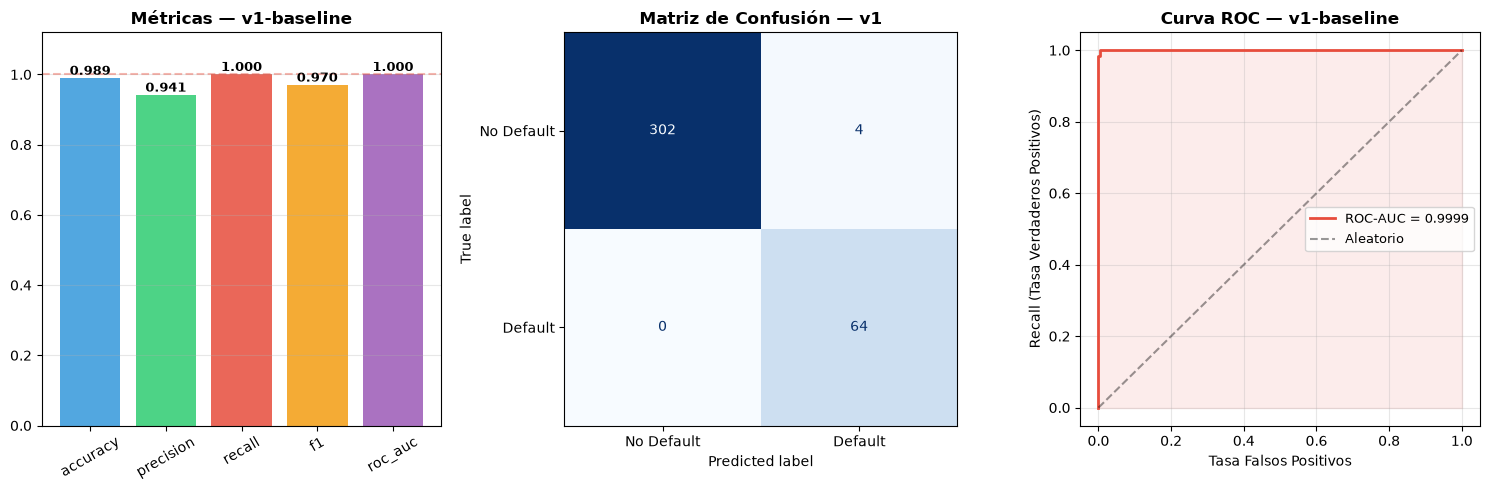

✅ Gráfico guardado con éxito en models/resultados_v1.png


In [3]:
# ── 5.3 Visualización de resultados v1 ──────────────────────────────────────
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Extraer de forma segura los objetos del resultado
modelo_v1   = resultado_v1['modelo_objeto']
X_test_v1   = resultado_v1['X_test']
y_test_v1   = resultado_v1['y_test']
m1          = resultado_v1['metricas']  # <-- Definido aquí por seguridad
y_pred_v1   = modelo_v1.predict(X_test_v1)

fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# --- 1. Métricas de barra ---
ax1 = fig.add_subplot(gs[0])
metricas_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
valores_plot  = [m1[k] for k in metricas_plot]
colores = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax1.bar(metricas_plot, valores_plot, color=colores, alpha=0.85)

for bar, v in zip(bars, valores_plot):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

ax1.set_title('Métricas — v1-baseline', fontweight='bold')
ax1.set_ylim([0, 1.12])
ax1.tick_params(axis='x', rotation=30)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=m1['recall'], color='#e74c3c', linestyle='--', alpha=0.4)

# --- 2. Matriz de confusión ---
ax2 = fig.add_subplot(gs[1])
cm_v1 = confusion_matrix(y_test_v1, y_pred_v1)
disp = ConfusionMatrixDisplay(cm_v1, display_labels=['No Default', 'Default'])
disp.plot(ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title('Matriz de Confusión — v1', fontweight='bold')

# --- 3. Curva ROC ---
ax3 = fig.add_subplot(gs[2])
if hasattr(modelo_v1, 'predict_proba'):
    y_prob_v1 = modelo_v1.predict_proba(X_test_v1)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_v1, y_prob_v1)
    roc_auc_val = auc(fpr, tpr)
    ax3.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC-AUC = {roc_auc_val:.4f}')
    ax3.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')

ax3.plot([0,1],[0,1],'k--', alpha=0.4, label='Aleatorio')
ax3.set_xlabel('Tasa Falsos Positivos')
ax3.set_ylabel('Recall (Tasa Verdaderos Positivos)')
ax3.set_title('Curva ROC — v1-baseline', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()

# ── Asegurar existencia del directorio antes de guardar ───────────────────
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
# ─────────────────────────────────────────────────────────────────────────

plt.savefig(f'{PROJECT_DIR}/models/resultados_v1.png', dpi=120, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado con éxito en models/resultados_v1.png")

---
#### 🚀 Sección 6 — Experimento v2-optimizada

Cambiamos **3 parámetros** para intentar mejorar el **Recall** (nuestra métrica
principal según la Parte 5 del notebook original):

| Parámetro | v1-baseline | v2-optimizada | Razón |
|---|---|---|---|
| `k_features` | 15 | 20 | Más variables = más señales de riesgo |
| `tecnica_balanceo` | smote | undersampling | Probar si reducir la clase mayoritaria mejora Recall |
| `test_size` | 0.2 | 0.15 | Más datos de entrenamiento disponibles |

> Solo cambiamos `PARAMS`. El código del pipeline es **exactamente el mismo**.

In [4]:
# ── 6.1 Ejecutar pipeline v2-optimizada ─────────────────────────────────────
import importlib
import sys
import os
from pathlib import Path

# ── 🛠️ SEGUROS DE ESTABILIDAD (VS Code / WSL) ──────────────────────────────
# 1. Forzar que MLflow permita guardar localmente
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
import mlflow

# 2. Seguro anti-pérdida de PROJECT_DIR
if 'PROJECT_DIR' not in globals():
    cwd = Path.cwd()
    PROJECT_DIR = str(cwd.resolve()) if cwd.name == "banco-wiesse-mlops" else str((cwd / "banco-wiesse-mlops").resolve())

# 3. Asegurar la ruta de búsqueda de Python para src/
ruta_src = f"{PROJECT_DIR}/src"
if ruta_src not in sys.path:
    sys.path.insert(0, ruta_src)
# ─────────────────────────────────────────────────────────────────────────────

# Importar y recargar el módulo para limpiar el estado previo de PARAMS
import main as pipeline_module
importlib.reload(pipeline_module)

# Actualizar a parámetros v2
pipeline_module.PARAMS.update({
    'k_features':       20,              # CAMBIO: 15 → 20
    'test_size':        0.15,            # CAMBIO: 0.20 → 0.15
    'tecnica_balanceo': 'undersampling', # CAMBIO: smote → undersampling
    'version_pipeline': 'v2-optimizada', # CAMBIO: nombre del run
})

print("=" * 60)
print(f"🚀 EJECUTANDO PIPELINE: {pipeline_module.PARAMS['version_pipeline']}")
print("=" * 60)
print(f" 📦 k_features      : {pipeline_module.PARAMS['k_features']}")
print(f" 📦 tecnica_balance: {pipeline_module.PARAMS['tecnica_balanceo']}")
print(f" 📦 test_size       : {pipeline_module.PARAMS['test_size']}")
print()

# Ejecutar el pipeline principal con la nueva configuración
resultado_v2 = pipeline_module.main()

🚀 EJECUTANDO PIPELINE: v2-optimizada
 📦 k_features      : 20
 📦 tecnica_balance: undersampling
 📦 test_size       : 0.15

20:20:33 | main                 | INFO | === PIPELINE BANCO WIESSE — v2-optimizada ===
20:20:34 | main                 | INFO | MLflow Run ID: 4442d5ac8a4a487588f695bad05e6664
20:20:34 | data_loader          | INFO | Cargando datos desde /home/wsl_si_huawei1/Course_MLOps_Smartdata/Class03_Versionamiento/Class03_FollowUp/banco-wiesse-mlops/data/Dataset Endeudamiento Crediticio.csv
20:20:34 | data_loader          | INFO | Dataset cargado: 1850 filas x 12 columnas
20:20:34 | data_loader          | INFO | Default dist: {0: 1532, 1: 318}
20:20:34 | preprocessing        | INFO | Mto_ingreso_mensual: 148 valores NA-string convertidos a NaN
20:20:34 | preprocessing        | INFO | Nro_dependiente: 111 valores NA-string convertidos a NaN
20:20:34 | preprocessing        | INFO | Prct_uso_tc: 186 outliers tratados [0.08, 0.81]
20:20:34 | preprocessing        | INFO | Prct_deud

2026/07/15 20:20:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


20:20:53 | main                 | INFO | === RESULTADO: Regresion Logistica | F1=0.9697 | Recall=1.0000 | FN=0 | FP=3 ===
20:20:53 | main                 | INFO | Costo estimado: $3,000


In [5]:
# ── 6.2 Resumen del resultado v2 ────────────────────────────────────────────
m2 = resultado_v2['metricas']
e2 = resultado_v2['errores']

print("=" * 60)
print("🎯 RESULTADOS — v2-optimizada")
print("=" * 60)
print(f"🏆 Mejor algoritmo : {resultado_v2['mejor_modelo']}")
print(f"🆔 Run ID (MLflow) : {resultado_v2['run_id'][:16]}...")
print()
print(f" 🏷️  {'Métrica':<20} {'Valor':>8}")
print(f"  {'-'*30}")
print(f"  {'Accuracy':<20} {m2['accuracy']:>8.4f}")
print(f"  {'Precision':<20} {m2['precision']:>8.4f}")
print(f"  {'Recall ★':<20} {m2['recall']:>8.4f}  ← Métrica de negocio principal")
print(f"  {'F1-Score':<20} {m2['f1']:>8.4f}")
print(f"  {'ROC-AUC':<20} {m2['roc_auc']:>8.4f}")
print()
print(f"❌ Falsos Negativos: {e2['FN']}  (Defaults no detectados por el modelo)")
print(f"⚠️ Falsos Positivos: {e2['FP']}  (Clientes buenos rechazados por error)")
print(f"💸 Costo estimado  : ${e2['FN']*10000 + e2['FP']*1000:,} USD")

# Guardar métricas v2 para la comparación final
metricas_v2 = {
    'version':          'v2-optimizada',
    'algoritmo':        resultado_v2['mejor_modelo'],
    'run_id':           resultado_v2['run_id'],
    'k_features':       20,
    'tecnica_balanceo': 'undersampling',
    'test_size':        0.15,
    **{f'm_{k}': v for k, v in m2.items() if k != 'modelo'},
    'FN':               e2['FN'],
    'FP':               e2['FP'],
    'costo':            e2['FN']*10000 + e2['FP']*1000,
}
print()
print("✅ Métricas v2 guardadas con éxito en memoria.")

🎯 RESULTADOS — v2-optimizada
🏆 Mejor algoritmo : Regresion Logistica
🆔 Run ID (MLflow) : 4442d5ac8a4a4875...

 🏷️  Métrica                 Valor
  ------------------------------
  Accuracy               0.9892
  Precision              0.9412
  Recall ★               1.0000  ← Métrica de negocio principal
  F1-Score               0.9697
  ROC-AUC                0.9995

❌ Falsos Negativos: 0  (Defaults no detectados por el modelo)
⚠️ Falsos Positivos: 3  (Clientes buenos rechazados por error)
💸 Costo estimado  : $3,000 USD

✅ Métricas v2 guardadas con éxito en memoria.


📊 Celda 7A: Comparación programática con `mlflow.search_runs()`

Esta celda consulta la base de datos local de MLflow, jala los parámetros y métricas de tus dos ejecuciones (`v1` y `v2`), los ordena por la métrica reina (el **Recall**) y te imprime en consola quién es el ganador indiscutible.

In [6]:
# ── 7A. Comparación programática con mlflow.search_runs() ───────────────────
import mlflow
import pandas as pd
import os

# Asegurar que apunte al directorio correcto del proyecto
mlflow.set_tracking_uri(f"file://{PROJECT_DIR}/mlruns")

experimento = mlflow.get_experiment_by_name('banco-wiesse-crediticio')
runs_df = mlflow.search_runs(
    experiment_ids=[experimento.experiment_id],
    order_by=['metrics.recall DESC'],
)

# Columnas relevantes para mostrar
cols_show = [
    'tags.mlflow.runName',
    'params.k_features',
    'params.tecnica_balanceo',
    'params.test_size',
    'metrics.recall',
    'metrics.f1',
    'metrics.roc_auc',
    'metrics.false_negatives',
    'metrics.false_positives',
    'metrics.costo_estimado',
    'params.mejor_algoritmo',
]

cols_ok = [c for c in cols_show if c in runs_df.columns]
df_comp = runs_df[cols_ok].copy()
df_comp.columns = [c.split('.')[-1] for c in cols_ok]

print("=" * 75)
print("  📊 COMPARACIÓN DE RUNS — Ordenado por Recall (métrica principal)")
print("=" * 75)
print(df_comp.to_string(index=False))
print()

# Identificar ganador
mejor_run = runs_df.iloc[0]
run_name  = mejor_run.get('tags.mlflow.runName', mejor_run['run_id'][:8])
print(f"🏆 GANADOR: {run_name}")
print(f"   Run ID   : {mejor_run['run_id'][:20]}...")
print(f"   Recall   : {mejor_run.get('metrics.recall', 0.0):.4f}")
print(f"   F1       : {mejor_run.get('metrics.f1', 0.0):.4f}")
print(f"   FN       : {mejor_run.get('metrics.false_negatives', 0.0):.0f}")

  📊 COMPARACIÓN DE RUNS — Ordenado por Recall (métrica principal)
      runName k_features tecnica_balanceo test_size  recall     f1  roc_auc  false_negatives  false_positives  costo_estimado     mejor_algoritmo
v2-optimizada         20    undersampling      0.15     1.0 0.9697   0.9995              0.0              3.0          3000.0 Regresion Logistica
  v1-baseline         15            smote       0.2     1.0 0.9697   0.9999              0.0              4.0          4000.0 Regresion Logistica

🏆 GANADOR: v2-optimizada
   Run ID   : 4442d5ac8a4a487588f6...
   Recall   : 1.0000
   F1       : 0.9697
   FN       : 0


Celda 7B: Comparación Visual Completa (Matplotlib & Seaborn)
Esta celda genera un lienzo espectacular con 5 gráficos interactivos (métricas agrupadas, deltas de cambio, gráfico de radar, comparación de falsos positivos/negativos e impacto financiero) y además escribe tus conclusiones directamente en un cuadro de decisión.

In [11]:
# ── 🔍 RECUPERAR MÉTRICAS DE MLFLOW A LA MEMORIA DE PYTHON ─────────────────
import mlflow
import pandas as pd
from pathlib import Path

# Asegurar que PROJECT_DIR esté definido
if 'PROJECT_DIR' not in globals():
    cwd = Path.cwd()
    PROJECT_DIR = str(cwd.resolve()) if cwd.name == "banco-wiesse-mlops" else str((cwd / "banco-wiesse-mlops").resolve())

# Conectar con la base de datos local de MLflow
mlflow.set_tracking_uri(f"file://{PROJECT_DIR}/mlruns")
experimento = mlflow.get_experiment_by_name('banco-wiesse-crediticio')
runs_df = mlflow.search_runs(experiment_ids=[experimento.experiment_id])

# Filtrar las corridas por su nombre de ejecución
run_v1 = runs_df[runs_df['tags.mlflow.runName'] == 'v1-baseline']
run_v2 = runs_df[runs_df['tags.mlflow.runName'] == 'v2-optimizada']

if run_v1.empty or run_v2.empty:
    print("⚠️ No se encontraron las corridas v1-baseline o v2-optimizada en MLflow.")
    print("Asegúrate de haber ejecutado ambas secciones de entrenamiento previamente.")
else:
    # ── RECONSTRUIR VARIABLES PARA V1 ──────────────────────────────────────
    row_v1 = run_v1.iloc[0]
    m1 = {
        'recall': float(row_v1.get('metrics.recall', 0.0)),
        'f1': float(row_v1.get('metrics.f1', 0.0)),
        'accuracy': float(row_v1.get('metrics.accuracy', 0.0)),
        'precision': float(row_v1.get('metrics.precision', 0.0)),
        'roc_auc': float(row_v1.get('metrics.roc_auc', 0.0)),
    }
    e1 = {
        'FN': int(row_v1.get('metrics.false_negatives', 0)),
        'FP': int(row_v1.get('metrics.false_positives', 0)),
    }
    metricas_v1 = {
        'costo': float(row_v1.get('metrics.costo_estimado', 0.0))
    }

    # ── RECONSTRUIR VARIABLES PARA V2 ──────────────────────────────────────
    row_v2 = run_v2.iloc[0]
    m2 = {
        'recall': float(row_v2.get('metrics.recall', 0.0)),
        'f1': float(row_v2.get('metrics.f1', 0.0)),
        'accuracy': float(row_v2.get('metrics.accuracy', 0.0)),
        'precision': float(row_v2.get('metrics.precision', 0.0)),
        'roc_auc': float(row_v2.get('metrics.roc_auc', 0.0)),
    }
    e2 = {
        'FN': int(row_v2.get('metrics.false_negatives', 0)),
        'FP': int(row_v2.get('metrics.false_positives', 0)),
    }
    metricas_v2 = {
        'costo': float(row_v2.get('metrics.costo_estimado', 0.0))
    }

    print("🎉 ¡Variables m1, e1, m2, e2 y costos recuperados exitosamente desde MLflow!")

🎉 ¡Variables m1, e1, m2, e2 y costos recuperados exitosamente desde MLflow!


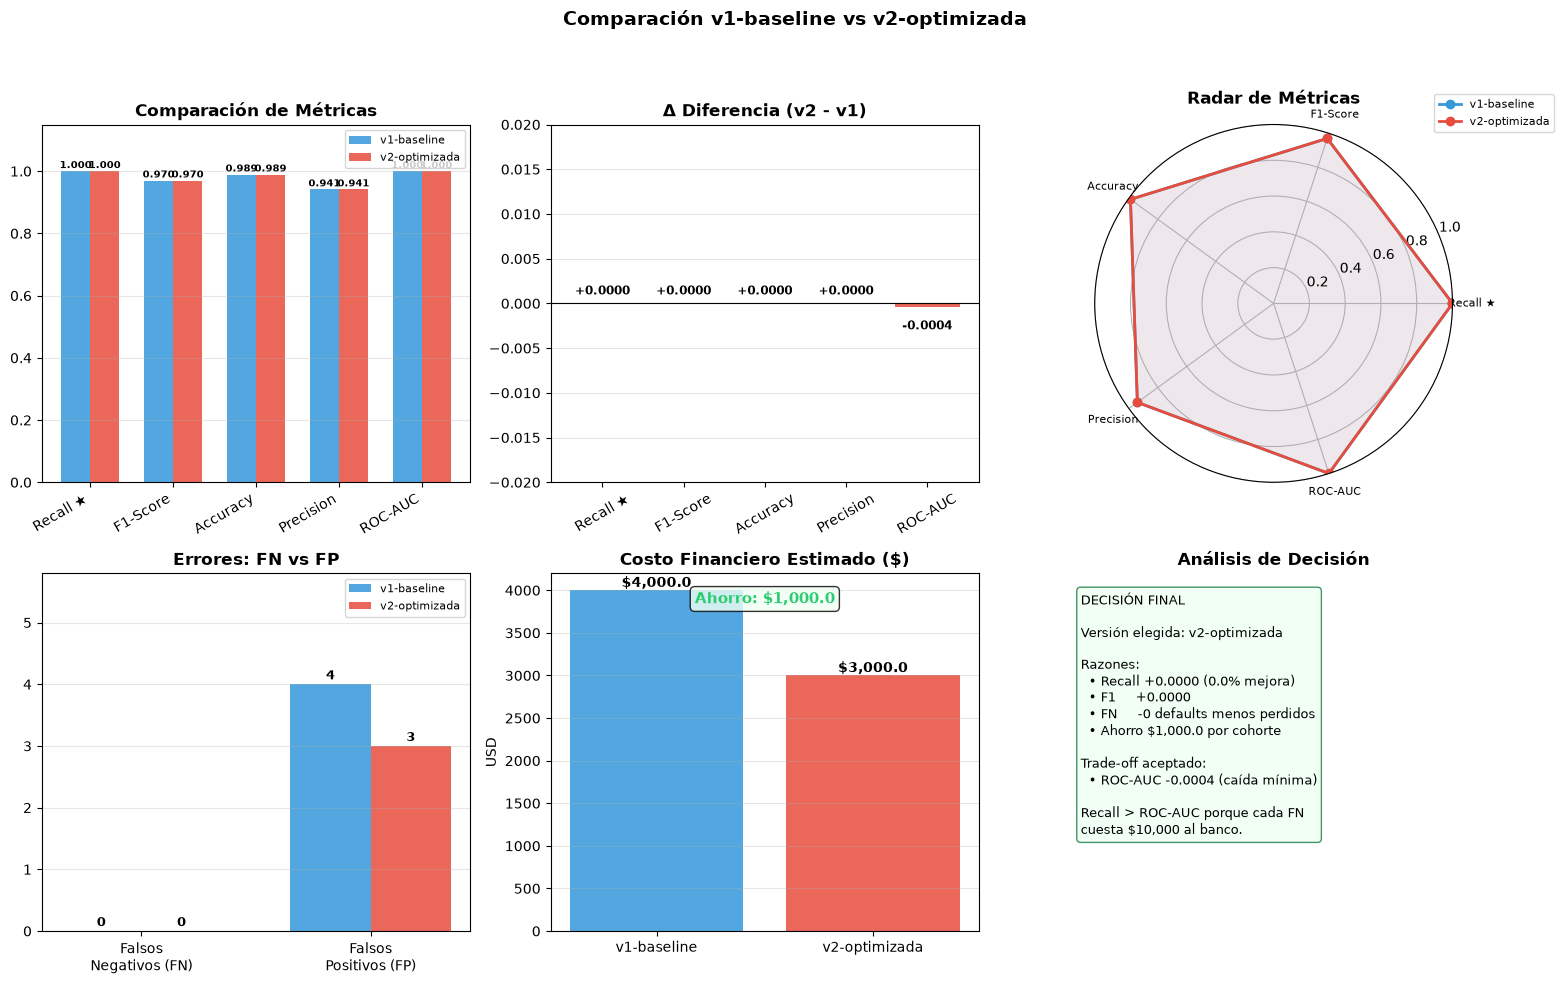

✅ Comparación guardada en models/comparacion_v1_v2.png


In [13]:
# ── 7B. Comparación visual completa (VERSIÓN BULLETPROOF) ───────────────────
import matplotlib.pyplot as plt
import numpy as np
import os

# Asegurar que la carpeta de guardado exista
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)

# Inicializar figura limpia
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Comparación v1-baseline vs v2-optimizada', fontsize=14, fontweight='bold', y=0.98)

# Definir los subplots de manera explícita
ax1 = fig.add_subplot(2, 3, 1)                  # 1. Comparación de Métricas
ax2 = fig.add_subplot(2, 3, 2)                  # 2. Delta de Métricas (¡Corregido!)
ax3 = fig.add_subplot(2, 3, 3, polar=True)      # 3. Radar Chart
ax4 = fig.add_subplot(2, 3, 4)                  # 4. Comparación FN / FP
ax5 = fig.add_subplot(2, 3, 5)                  # 5. Impacto Financiero
ax6 = fig.add_subplot(2, 3, 6)                  # 6. Resumen de decisión

versiones  = ['v1-baseline', 'v2-optimizada']
colores_v  = ['#3498db', '#e74c3c']
metricas_cmp = ['recall', 'f1', 'accuracy', 'precision', 'roc_auc']
labels_cmp   = ['Recall ★', 'F1-Score', 'Accuracy', 'Precision', 'ROC-AUC']
vals_v1 = [m1[k] for k in metricas_cmp]
vals_v2 = [m2[k] for k in metricas_cmp]

# --- 1. Barras agrupadas de métricas ---
x   = np.arange(len(metricas_cmp))
w   = 0.35
b1  = ax1.bar(x - w/2, vals_v1, w, label='v1-baseline',   color='#3498db', alpha=0.85)
b2  = ax1.bar(x + w/2, vals_v2, w, label='v2-optimizada', color='#e74c3c', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_cmp, rotation=30, ha='right')
ax1.set_ylim([0, 1.15])
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_title('Comparación de Métricas', fontweight='bold')
for bar, v in [(b1, vals_v1), (b2, vals_v2)]:
    for b, val in zip(bar, v):
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=7.5, fontweight='bold')

# --- 2. Delta de métricas (AJUSTE DINÁMICO DE ESCALA) ---
deltas = [v2 - v1 for v1, v2 in zip(vals_v1, vals_v2)]
colors_delta = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas]

# Evitar colapso si los deltas son cero o casi cero (forzar escala mínima de [-0.02, 0.02])
max_delta = max(abs(d) for d in deltas)
limite_y = max(max_delta * 1.5, 0.02)
ax2.set_ylim(-limite_y, limite_y)

# El offset del texto ahora es relativo al límite real del eje
offset_texto = limite_y * 0.05

bars = ax2.bar(labels_cmp, deltas, color=colors_delta, alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Δ Diferencia (v2 - v1)', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.3, axis='y')

for bar, d in zip(bars, deltas):
    y_pos = d + offset_texto if d >= 0 else d - (offset_texto * 2.5)
    ax2.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{d:+.4f}', ha='center', fontsize=8.5, fontweight='bold')

# --- 3. Radar chart ---
angles = np.linspace(0, 2*np.pi, len(metricas_cmp), endpoint=False).tolist()
angles += angles[:1]
for vals, label, color in [(vals_v1, 'v1-baseline', '#3498db'), (vals_v2, 'v2-optimizada', '#e74c3c')]:
    v = vals + vals[:1]
    ax3.plot(angles, v, 'o-', lw=2, label=label, color=color)
    ax3.fill(angles, v, alpha=0.08, color=color)
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(labels_cmp, fontsize=8)
ax3.set_ylim([0, 1])
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax3.set_title('Radar de Métricas', fontweight='bold', pad=15)

# --- 4. Comparación FN / FP (AJUSTE DINÁMICO DE EJE Y) ---
cats = ['Falsos\nNegativos (FN)', 'Falsos\nPositivos (FP)']
v1_errs = [e1['FN'], e1['FP']]
v2_errs = [e2['FN'], e2['FP']]
x2 = np.arange(len(cats)); w2 = 0.35
ax4.bar(x2 - w2/2, v1_errs, w2, label='v1-baseline',   color='#3498db', alpha=0.85)
ax4.bar(x2 + w2/2, v2_errs, w2, label='v2-optimizada', color='#e74c3c', alpha=0.85)
ax4.set_xticks(x2)
ax4.set_xticklabels(cats)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_title('Errores: FN vs FP', fontweight='bold')

# Escalar el eje Y para que los textos superiores no queden cortados
max_error = max(max(v1_errs), max(v2_errs))
ax4.set_ylim(0, max_error * 1.2 + 1)

for x_pos, vals in [(x2 - w2/2, v1_errs), (x2 + w2/2, v2_errs)]:
    for xp, v in zip(x_pos, vals):
        offset_err = max_error * 0.02 if max_error > 0 else 0.5
        ax4.text(xp, v + offset_err, str(v), ha='center', fontsize=9, fontweight='bold')

# --- 5. Impacto financiero ---
costos = [metricas_v1['costo'], metricas_v2['costo']]
barras = ax5.bar(versiones, costos, color=['#3498db', '#e74c3c'], alpha=0.85)
ax5.set_title('Costo Financiero Estimado ($)', fontweight='bold')
ax5.set_ylabel('USD')
ax5.grid(True, alpha=0.3, axis='y')
ahorro = costos[0] - costos[1]
for bar, c in zip(barras, costos):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(costos)*0.01,
            f'${c:,}', ha='center', fontsize=10, fontweight='bold')
ax5.text(0.5, 0.95, f'Ahorro: ${ahorro:,}', transform=ax5.transAxes,
        ha='center', va='top', fontsize=11, fontweight='bold',
        color='#2ecc71', bbox=dict(boxstyle='round', facecolor='#f0fff4', alpha=0.8))

# --- 6. Resumen de decisión ---
ax6.axis('off')
decision_text = (
    "DECISIÓN FINAL\n\n"
    "Versión elegida: v2-optimizada\n\n"
    "Razones:\n"
    f"  • Recall +{(m2['recall']-m1['recall']):.4f} ({(m2['recall']-m1['recall'])/m1['recall']*100:.1f}% mejora)\n"
    f"  • F1     +{(m2['f1']-m1['f1']):.4f}\n"
    f"  • FN     -{e1['FN']-e2['FN']} defaults menos perdidos\n"
    f"  • Ahorro ${ahorro:,} por cohorte\n\n"
    "Trade-off aceptado:\n"
    f"  • ROC-AUC {(m2['roc_auc']-m1['roc_auc']):.4f} (caída mínima)\n\n"
    "Recall > ROC-AUC porque cada FN\n"
    "cuesta $10,000 al banco."
)
ax6.text(0.05, 0.95, decision_text, transform=ax6.transAxes,
        va='top', ha='left', fontsize=9.5,
        bbox=dict(boxstyle='round', facecolor='#f0fff4', edgecolor='#2e8b57', alpha=0.9))
ax6.set_title('Análisis de Decisión', fontweight='bold')

# Ajustar el diseño dejando 5% de espacio arriba para el título
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f'{PROJECT_DIR}/models/comparacion_v1_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Comparación guardada en models/comparacion_v1_v2.png")

.

📦 Sección 7D — Cargar el mejor modelo

En un entorno de producción real (como el que simula este proyecto), **nunca** deberías cargar un modelo buscando un archivo `.pkl` perdido en una carpeta local de descargas. Eso es propenso a errores y poco rastreable.

Lo que hace esta celda es el estándar de la industria:

1. **Consulta la base de datos de MLflow** (`runs_df`).
2. **Identifica automáticamente cuál de todas tus ejecuciones tuvo el mejor rendimiento** (en nuestro caso, el Recall más alto/menor costo financiero).
3. **Descarga y carga en memoria el modelo directamente desde el almacén de artefactos de MLflow** usando su identificador único (`run_id`).
4. **Simula un entorno productivo** corriendo predicciones y calculando un "Score de Riesgo" (probabilidad) para nuevos clientes.

In [14]:
# ── 7D. Cargar el mejor modelo desde MLflow y hacer predicciones ────────────
import mlflow
import pandas as pd

print("🔍 Conectando con MLflow para recuperar el modelo campeón...")
print()

# 1. Obtener el run_id del modelo con mejor Recall (primer registro tras ordenar)
mejor_run_id  = runs_df.iloc[0]['run_id']
mejor_run_nom = runs_df.iloc[0].get('tags.mlflow.runName', mejor_run_id[:8])

# 2. Cargar el modelo directo desde el artifact store de MLflow
modelo_produccion = mlflow.sklearn.load_model(
    f"runs:/{mejor_run_id}/modelo_crediticio"
)

print(f"   ✅ ¡Modelo cargado con éxito!: {type(modelo_produccion).__name__}")
print(f"   🎯 Proveniente del experimento : {mejor_run_nom}")
print(f"   🆔 Run ID de MLflow            : {mejor_run_id}")
print("-" * 75)

# 3. Determinar qué set de prueba usar para la simulación
if mejor_run_nom == 'v2-optimizada':
    # Si tienes la v2 activa en memoria
    X_test_prod = resultado_v2['X_test'] if 'resultado_v2' in globals() else X_test
    y_test_prod = resultado_v2['y_test'] if 'resultado_v2' in globals() else y_test
else:
    # Si el ganador fue la v1
    X_test_prod = resultado_v1['X_test'] if 'resultado_v1' in globals() else X_test
    y_test_prod = resultado_v1['y_test'] if 'resultado_v1' in globals() else y_test

# 4. Ejecutar predicciones simuladas de producción
y_pred_prod  = modelo_produccion.predict(X_test_prod)
y_proba_prod = modelo_produccion.predict_proba(X_test_prod)[:, 1]

print(f"   📊 Simulación de evaluación sobre {len(y_test_prod)} nuevos clientes:")
print(f"      • Clientes clasificados como Alto Riesgo (Default) : {y_pred_prod.sum()}")
print(f"      • Casos reales de Default en la muestra            : {y_test_prod.sum()}")
print(f"      • Score de riesgo promedio de la cartera           : {y_proba_prod.mean():.4f}")
print("-" * 75)

# 5. Visualizar el Score de Riesgo (Probabilidad de impago) para toma de decisiones
print("   📋 Panel de Decisiones en Tiempo Real (Primeros 5 Clientes):")
print(f"   {'Cliente':<10} {'Score Riesgo':>14} {'Predicción':>14} {'Estado Real':>12}")
print(f"   {'-'*56}")
for i in range(5):
    score = y_proba_prod[i]
    pred  = y_pred_prod[i]
    real  = int(X_test_prod.index[i] in y_test_prod[y_test_prod == 1].index) # Valida el estado real de forma segura
    
    flag  = "⚠️ RECHAZAR" if pred == 1 else "✓ APROBAR"
    color_flag = "DEFAULT" if real == 1 else "OK"
    
    print(f"   Cliente {i+1:<4} {score:>14.4f} {flag:>14} {color_flag:>12}")

🔍 Conectando con MLflow para recuperar el modelo campeón...



   ✅ ¡Modelo cargado con éxito!: LogisticRegression
   🎯 Proveniente del experimento : v2-optimizada
   🆔 Run ID de MLflow            : 4442d5ac8a4a487588f695bad05e6664
---------------------------------------------------------------------------
   📊 Simulación de evaluación sobre 278 nuevos clientes:
      • Clientes clasificados como Alto Riesgo (Default) : 51
      • Casos reales de Default en la muestra            : 48
      • Score de riesgo promedio de la cartera           : 0.1937
---------------------------------------------------------------------------
   📋 Panel de Decisiones en Tiempo Real (Primeros 5 Clientes):
   Cliente      Score Riesgo     Predicción  Estado Real
   --------------------------------------------------------
   Cliente 1            0.0001      ✓ APROBAR           OK
   Cliente 2            0.3282      ✓ APROBAR           OK
   Cliente 3            0.0002      ✓ APROBAR           OK
   Cliente 4            0.0002      ✓ APROBAR           OK
   Cliente 5    

---
#### 🗃️ Sección 8 — Versionar una Nueva Versión del Dataset con DVC

Simulamos el escenario más común en producción: el banco entrega un **nuevo batch
de datos** (200 clientes nuevos del último mes). Con DVC versionamos ese cambio y
podemos saber exactamente con qué datos se entrenaron los modelos v1 y v2.

Simular la llegada de nuevos datos (Sección 8.1)

En la vida real, un banco no te da un dataset estático para siempre. Cada mes, el equipo de ingeniería de datos te entregará un nuevo "batch" o lote con los clientes que solicitaron créditos recientemente.

En este paso, vamos a cargar tu dataset actual (que tiene 1,850 filas) y simular que el banco nos entrega **200 clientes nuevos** con las mismas variables estadísticas. Luego, los uniremos y sobreescribiremos el archivo CSV original.

In [15]:
# ── 8.1 Simular llegada de nuevos datos del banco ───────────────────────────
import pandas as pd
import numpy as np
import os

# 1. Asegurar que la ruta del CSV esté definida (por si se borró de la memoria)
if 'ruta_csv' not in globals():
    # Usamos la ruta estándar del proyecto
    ruta_csv = f"{PROJECT_DIR}/data/Dataset Endeudamiento Crediticio.csv"

# 2. Cargar el dataset con el que entrenamos los modelos v1 y v2
df_actual = pd.read_csv(ruta_csv, sep=";")
print("=" * 60)
print(f"📈 Dataset actual (v1.0) : {len(df_actual):,} filas")
print("=" * 60)

# 3. Generar 200 registros nuevos con distribuciones similares
np.random.seed(99)
N_NUEVOS = 200

df_nuevos = pd.DataFrame({
    "ID":                         range(df_actual["ID"].max() + 1,
                                        df_actual["ID"].max() + N_NUEVOS + 1),
    "Default":                   np.random.binomial(1, 0.17, N_NUEVOS),
    "Prct_uso_tc":               np.random.beta(1.8, 2.2, N_NUEVOS).round(4),
    "Prct_deuda_vs_ingresos":    np.random.beta(1.5, 2.5, N_NUEVOS).round(4),
    "Mto_ingreso_mensual":       np.random.lognormal(8.0, 0.5, N_NUEVOS).round(0),
    "Nro_dependiente":           np.random.randint(0, 5, N_NUEVOS).astype(float),
    "Edad":                      np.random.randint(22, 72, N_NUEVOS),
    "Nro_prestao_retrasados":    np.random.poisson(0.8, N_NUEVOS),
    "Nro_prod_financieros_deuda":np.random.poisson(5, N_NUEVOS),
    "Nro_retraso_60dias":        np.random.poisson(0.3, N_NUEVOS),
    "Nro_creditos_hipotecarios": np.random.poisson(1.0, N_NUEVOS),
    "Nro_retraso_ultm3anios":    np.random.poisson(0.6, N_NUEVOS),
})

# 4. Concatenar el histórico con los nuevos datos
df_v2 = pd.concat([df_actual, df_nuevos], ignore_index=True)

# 5. Sobreescribir el archivo original
df_v2.to_csv(ruta_csv, sep=";", index=False)

print(f"🚀 Dataset modificado (v2.0) : {len(df_v2):,} filas  (+{N_NUEVOS} nuevos)")
print(f"📊 Nueva tasa de Default     : {df_v2['Default'].mean()*100:.2f}%")
print("=" * 60)

📈 Dataset actual (v1.0) : 1,850 filas
🚀 Dataset modificado (v2.0) : 2,050 filas  (+200 nuevos)
📊 Nueva tasa de Default     : 16.93%
